# Synthetic mode recovery visualiser

Compare each ideal input mode with a representative matched DMD mode from the resolved and resolved-plus-background uncertainty ensembles, and with the feasible background-only mode having the closest period. For each signal-bearing ensemble, the plotted mode is the actual successful member whose similarity is closest to the median over successful matches. Recovered phasors are phase-aligned to the input and their amplitudes are retained.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

cwd = Path(os.getcwd()).resolve()
PROJECT_ROOT = next(
    path for path in (cwd, *cwd.parents)
    if (path / 'src' / 'msc_thesis').is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_th

## Configuration

`visualisation_nmax` is the single spherical-harmonic truncation used to construct every record, run every DMD case, project every snapshot, and calculate every similarity. `visualisation_n_ensemble` controls how many stored covariance-perturbation members are considered for both signal-bearing columns. The three DMD setups remain separate so their rank and Hankel settings can be changed independently without changing the shared degree truncation.

In [9]:
mode_numbers = ['62', '6', '13', '48', '45', '1', '32']
mode_numbers = [str(mode_number) for mode_number in mode_numbers]

# Shared by the ideal, resolved, signal-plus-background, and null cases.
visualisation_nmax = 9
visualisation_n_ensemble = 10

resolved_setup = {
    'svd_rank': 0.999,
    'dmd_settings': {
        'dmd_type': 'exact',
        'hankel_flag': True,
        'embedding_d': 4,
        'weight_flag': True,
    },
}

signal_background_setup = {
    'svd_rank': 0.9999,
    'dmd_settings': {
        'dmd_type': 'exact',
        'hankel_flag': True,
        'embedding_d': 4,
        'weight_flag': True,
    },
}

null_background_setup = {
    'svd_rank': 0.999,
    'dmd_settings': {
        'dmd_type': 'exact',
        'hankel_flag': True,
        'embedding_d': 4,
        'weight_flag': True,
    },
}

null_period_limits = (3, 100)
null_min_quality_factor = None
null_seed = 42

## Construct and recover modes

The resolved and resolved-plus-background ensembles use their existing mode-matching rules. For each input mode, the median similarity is calculated over successful matches only; the closest actual ensemble member is then reconstructed to obtain its DMD phasor, eigenvalue, and amplitude. If no member recovers a mode, its panel remains empty. The null column is not called a match: it selects the recovered background-only mode nearest to the input period within the open 3–100 year feasibility window, with no quality-factor constraint.

In [10]:
visualisation_rows, syn_suite_info, recovered_mode_sets = (
    Build_Synthetic_Mode_Visualisation_Data(
        mode_numbers=mode_numbers,
        nmax=visualisation_nmax,
        resolved_setup=resolved_setup,
        signal_background_setup=signal_background_setup,
        null_background_setup=null_background_setup,
        n_ensemble=visualisation_n_ensemble,
        null_period_limits=null_period_limits,
        null_min_quality_factor=null_min_quality_factor,
        null_seed=null_seed,
    )
)

## Plot recovered snapshots

Each row has one symmetric colour scale determined only by the maximum absolute real-phasor value in its first three columns. The null snapshot uses that same scale and may therefore clip rather than making the input and matched modes illegible. A missing resolved or signal-plus-background match is labelled `No match`.

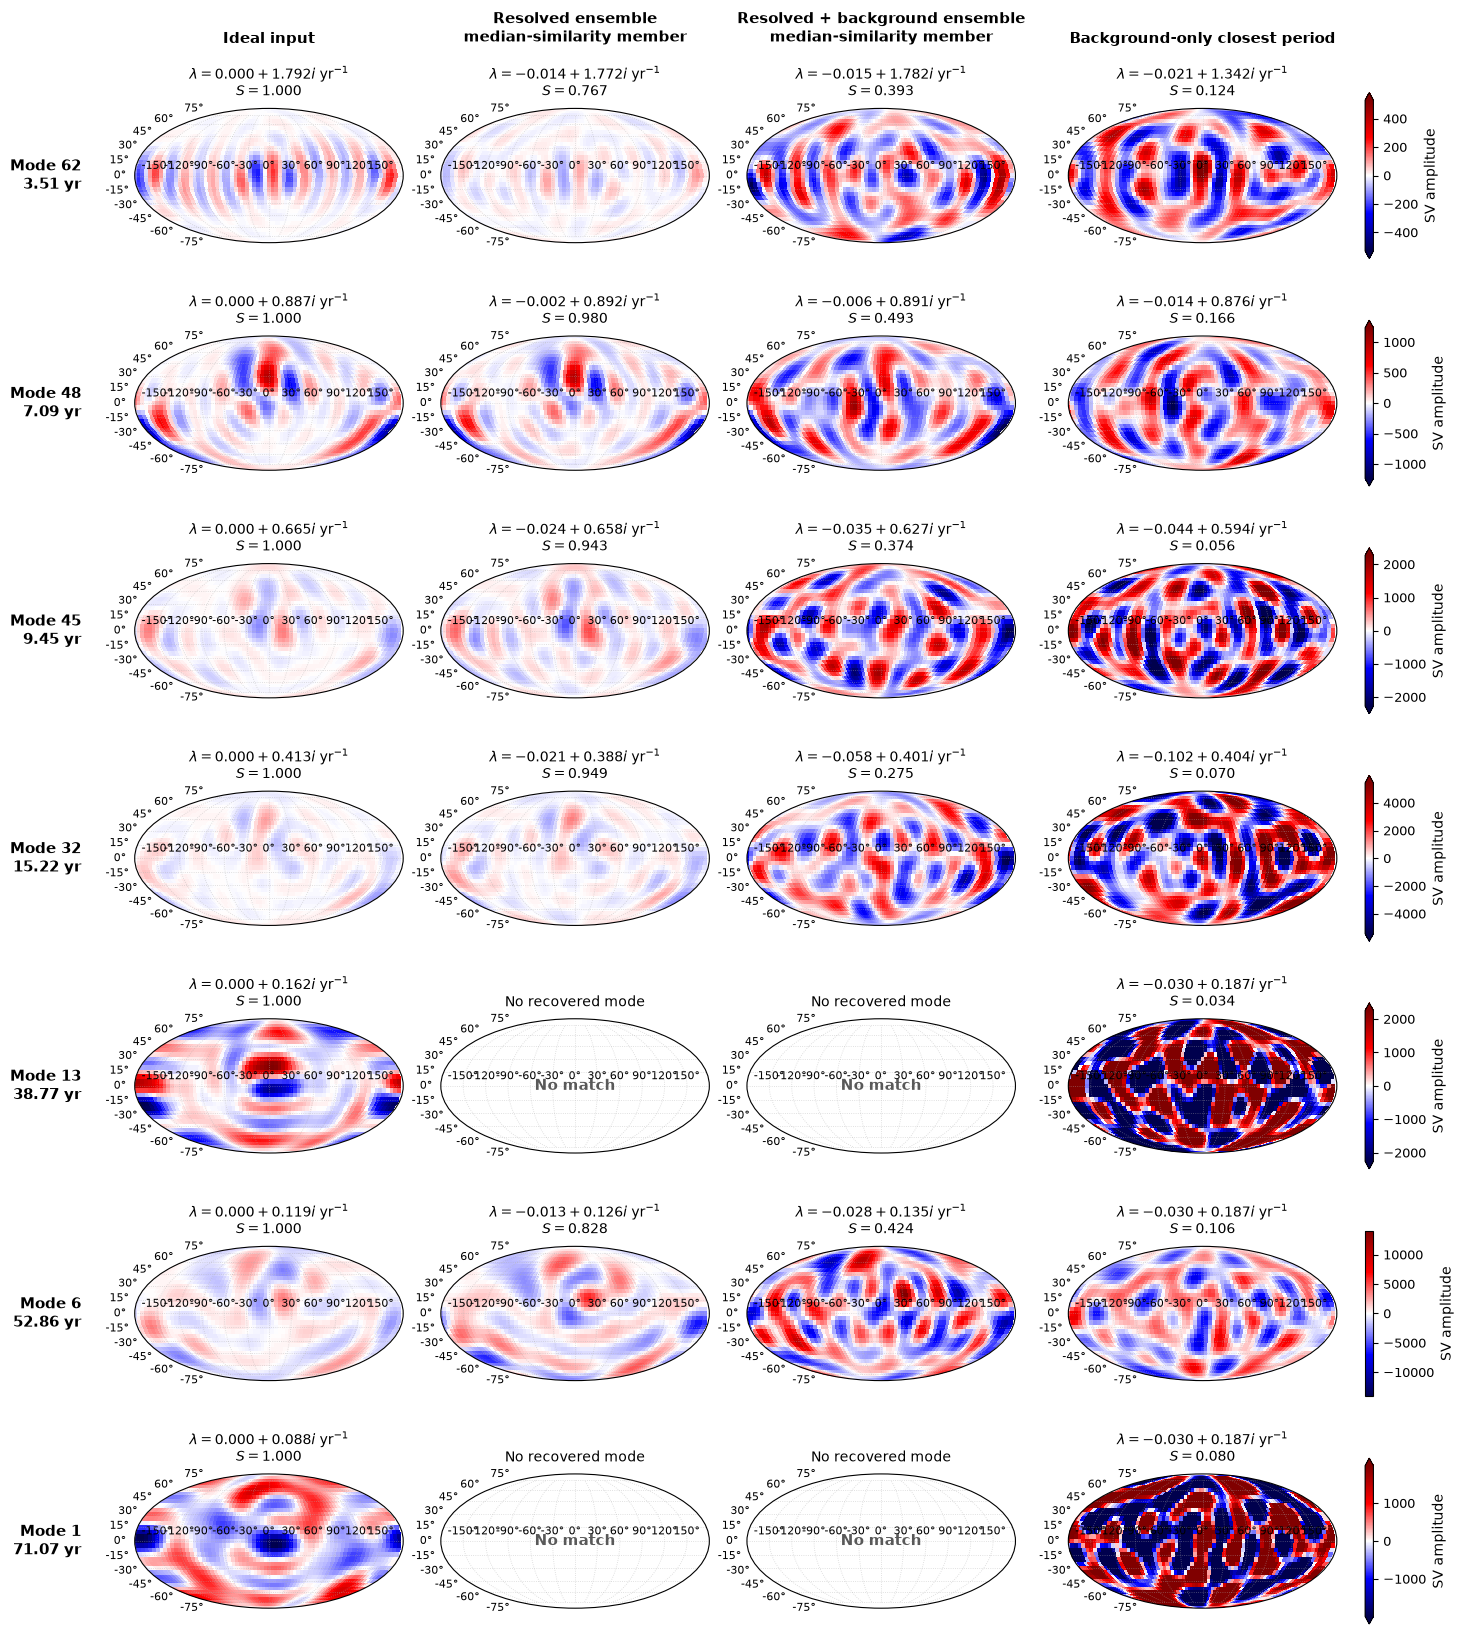

In [11]:
mode_figure, mode_axes = Plot_Synthetic_Mode_Visualisation(
    visualisation_rows,
    figure_width=2 * text_width,
    font_size=10,
)
plt.show()

In [ ]:
# Audit the selected ensemble members and any empty panels.
ensemble_contexts = {
    'resolved': 'Resolved ensemble',
    'signal_background': 'Resolved + background ensemble',
}
for mode_key, row in visualisation_rows.items():
    print(f'Mode {mode_key}')
    for context_key, context_label in ensemble_contexts.items():
        selection = recovered_mode_sets[f'{context_key}_selections'][mode_key]
        if selection is None:
            print(f'  {context_label}: no match')
        else:
            print(
                f"  {context_label}: member {selection['ensemble_index']}, "
                f"selected S={selection['selected_similarity']:.3f}, "
                f"median S={selection['median_similarity']:.3f}, "
                f"successful matches={selection['successful_match_count']}/"
                f"{visualisation_n_ensemble}"
            )
    if row['null_background'] is None:
        print('  Background-only closest period: no eligible mode')